In [51]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Rescaling
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

In [52]:
# 1. Dosya Yolu
DATA_DIR = '/kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset/IMG_CLASSES'

BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 50

print("Kullanılabilir GPU Sayısı: ", len(tf.config.list_physical_devices('GPU')))

Kullanılabilir GPU Sayısı:  2


In [53]:
# 2. YENİ VE HIZLI VERİ OKUMA (tf.data)
print("\nVeriler yükleniyor (tf.data ile)...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Sınıf sayısını dinamik olarak alalım
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Bulunan sınıflar: {class_names}")


Veriler yükleniyor (tf.data ile)...
Found 27153 files belonging to 10 classes.
Using 21723 files for training.
Found 27153 files belonging to 10 classes.
Using 5430 files for validation.
Bulunan sınıflar: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


In [54]:
# 3. DARBOĞAZI ÇÖZEN SİHİRLİ DOKUNUŞ (Prefetch & Cache)
# İşlemci veriyi RAM'de hazır bekletir, GPU hiç beklemeden sömürür.
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [55]:
# 4. GPU'DA ÇALIŞAN VERİ ÇOĞALTMA (Data Augmentation) Katmanları
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="data_augmentation")

In [56]:
# 5. Model Oluşturucu Fonksiyon
def build_model(base_model_class, model_name):
    # Base modeli yükle
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False 
    
    # Yeni ve optimize mimari (Augmentation artık modelin içinde)
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs) # Veri çoğaltma direkt GPU'da yapılıyor
    x = Rescaling(1./255)(x)      # Piksel değerlerini 0-1 arasına çekme
    
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=predictions, name=model_name)
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [57]:
# 6. Modellerin Tanımlanması
models = {
    "MobileNet_V1": build_model(MobileNet, "MobileNet_V1"),
    "MobileNet_V2": build_model(MobileNetV2, "MobileNet_V2"),
    "MobileNet_V3": build_model(MobileNetV3Large, "MobileNet_V3")
}

history_dict = {}

In [58]:
# 7. Eğitim Döngüsü
for name, model in models.items():
    print(f"\n{'='*50}\n{name} Eğitimi Başlıyor...\n{'='*50}")
    
    checkpoint = ModelCheckpoint(f"{name}_best_model.keras", monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
    early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
    
    history = model.fit(
        train_ds,           # Yeni optimize veri setimiz
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[checkpoint, early_stop]
    )
    
    history_dict[name] = history.history

print("\nTüm modellerin eğitimi tamamlandı!")


MobileNet_V1 Eğitimi Başlıyor...
Epoch 1/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4644 - loss: 1.4361
Epoch 1: val_accuracy improved from -inf to 0.58508, saving model to MobileNet_V1_best_model.keras
679/679 ━━━━━━━━━━━━━━━━━━━━ 96s 65ms/step - accuracy: 0.4645 - loss: 1.4358 - val_accuracy: 0.5851 - val_loss: 1.0193
Epoch 2/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5845 - loss: 1.0637
Epoch 2: val_accuracy improved from 0.58508 to 0.64015, saving model to MobileNet_V1_best_model.keras
679/679 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - accuracy: 0.5845 - loss: 1.0637 - val_accuracy: 0.6401 - val_loss: 0.9250
Epoch 3/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6078 - loss: 1.0002
Epoch 3: val_accuracy improved from 0.64015 to 0.64512, saving model to MobileNet_V1_best_model.keras
679/679 ━━━━━━━━━━━━━━━━━━━━ 39s 58ms/step - accuracy: 0.6078 - loss: 1.0002 - val_accuracy: 0.6451 - val_loss: 0.9116
Epoch 4/50
678/679 ━━━━━━━━━━━━━━━━━━━━ 0s 46

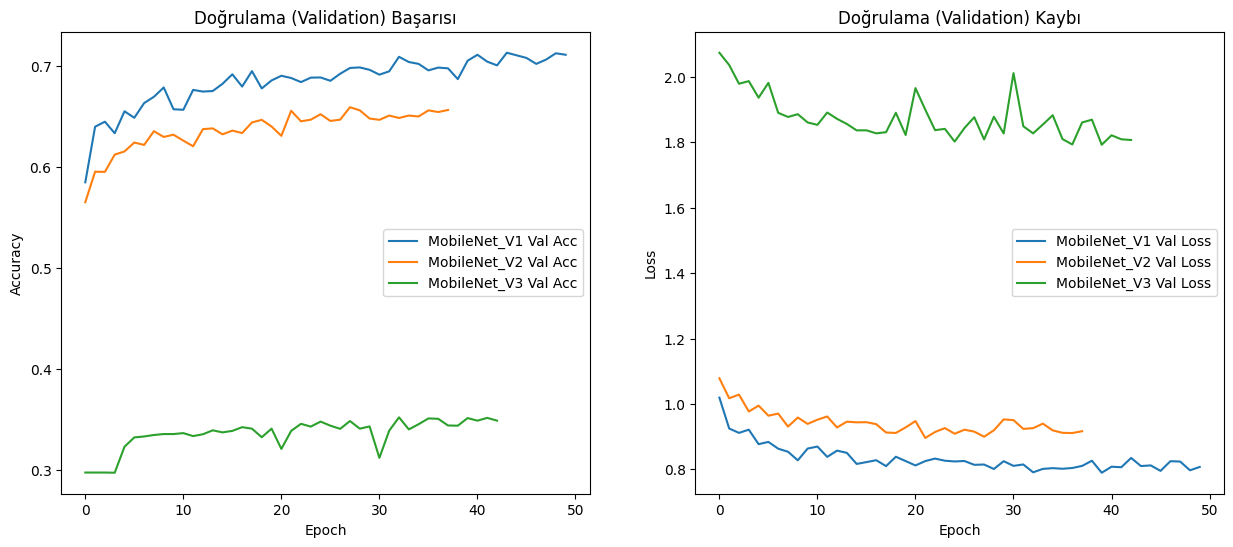

In [59]:
# 8. Grafikler
def plot_results(history_dict):
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 2, 1)
    for name, history in history_dict.items():
        plt.plot(history['val_accuracy'], label=f'{name} Val Acc')
    plt.title('Doğrulama (Validation) Başarısı')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    for name, history in history_dict.items():
        plt.plot(history['val_loss'], label=f'{name} Val Loss')
    plt.title('Doğrulama (Validation) Kaybı')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()

plot_results(history_dict)